# Toy Model: Analysis

In [1]:
sup_method='moekratter' # options: 'simple', 'moekratter', '50', 'snow  '

from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl
import pickle
from scipy import stats
import scipy


# my preferred settings
mpl.rc('lines',linewidth = 1.5)
mpl.rc('font',size = 14)
mpl.rc('axes',labelsize = 16, linewidth=1.25)
mpl.rc('xtick',labelsize = 16)
mpl.rc('ytick',labelsize = 16)
# enable math fonts
mpl.rc('mathtext', default = 'regular')
plt.rcParams['savefig.dpi'] = 400 

import seaborn as sns 

from sbin.SuppressionSimulator import SuppressionSimulator
from sbin.simulation_helper import run_trials
from sbin.plotting_utilities import plot_hist_confidence, plot_ecdf_confidence, ecdf_grid
from sbin.complexity import create_complexity_df
from sbin.statistics_utilities import *


if sup_method=='simple':
    from sbin.suppression_utilities import suppression_factor_simple as my_suppression_factor
elif sup_method=='moekratter':
    from sbin.suppression_utilities import suppression_factor_mk21 as my_suppression_factor
elif sup_method=='50':
    from sbin.suppression_utilities import suppression_factor_50 as my_suppression_factor  
elif sup_method=='snow':
    from sbin.suppression_utilities import suppression_factor_snow as my_suppression_factor
else:
    raise

teff_limit = (4700, 6500)
teff_limit = None


In [2]:
import builtins
import atexit

log_file = open('toy_model.log', 'a')
_builtin_print = builtins.print

def print(*args, **kwargs):
    _builtin_print(*args, **kwargs)
    log_kwargs = kwargs.copy()
    log_kwargs['file'] = log_file
    _builtin_print(*args, **log_kwargs)
    log_file.flush()


print("===========================================")
print("Running toy model with... \n suppression method: " + sup_method + "\n teff limit: " + str(teff_limit))



Running toy model with... 
 suppression method: moekratter
 teff limit: None


### Read in data saved from Filtering

In [3]:
with open("filtered_data.pkl", "rb") as f:
     data = pickle.load(f)
          
# conjoined list of binaries
binaries = data["binaries_filtered"]

allbinaries = data["binaries_unfiltered"]

# separation values (one per KOI) for each binary
binary_separations = binaries.groupby('KOI')['SepAU'].first().values
allbinaries_separations = allbinaries.groupby('KOI')['SepAU'].first().values

# all KOIs that are presumed single
singles = data["kois_filtered_cc"]

if teff_limit is not None:
    binaries = binaries[ (binaries['steff_adopt']>teff_limit[0]) & (binaries['steff_adopt']<teff_limit[1]) ]
    singles = singles[ (singles['koi_steff']>teff_limit[0]) & (singles['koi_steff']<teff_limit[1]) ]
    tflag = str(teff_limit[0]) + "-" + str(teff_limit[1]) + "K"
else:
    tflag = "allTeff"

In [4]:
print("\nBASIC INFO:")
print(f"There are {len(binaries)} planets in binaries and {len(singles)} single KOIs in the sample")
print(f"There are {len(binaries[binaries['SepAU']<100])} planets in binaries with separation < 100 AU")
print(f"There are {len(binary_separations)} systems in binaries")
print(f"There are {len(binary_separations[binary_separations<100])} systems in binaries with separation < 100 AU")


BASIC INFO:
There are 195 planets in binaries and 662 single KOIs in the sample
There are 59 planets in binaries with separation < 100 AU
There are 126 systems in binaries
There are 35 systems in binaries with separation < 100 AU


# Toy Model

### Suppress the KOIs

In [5]:

# ------------------------------------------------------------------
#  Initialise the simulator
# ------------------------------------------------------------------
KeplerSimulator = SuppressionSimulator(
    planets_cat=singles,
    sup_function=my_suppression_factor,
    join_col="KOI",
    prad_col="koi_prad",
    teff_col="koi_steff",
    random_state=42,             
)

# ------------------------------------------------------------------
#  Run it
# ------------------------------------------------------------------
max_a_draw = 100.
ntrials = 1000
res_systems, res_planets, res_plradius = run_trials(
    simulator=KeplerSimulator,
    n_trials=ntrials,
    max_a_draw=max_a_draw)

print(f"Simulated {ntrials} trials with maximum a draw of {max_a_draw} AU")
print("Simulated number of systems (planets suppressed): " + str(len(res_planets.survived_systems['a_values'])))
print("Simulated number of systems (systems suppressed): " + str(len(res_systems.survived_systems['a_values'])))
print("Simulated number of systems (large planets more suppressed): " + str(len(res_plradius.survived_systems['a_values'])))


Simulated 1000 trials with maximum a draw of 100.0 AU
Simulated number of systems (planets suppressed): 164275
Simulated number of systems (systems suppressed): 136658
Simulated number of systems (large planets more suppressed): 105512



=== linear scale ===
KS statistic (binaries vs singles): 0.15192790209432128, p-value: 0.14690377665304846
KS statistic (simulated systems vs singles): 0.15074133556039182, p-value: 0.12333468806181636
KS statistic (simulated radius-dependent vs singles): 0.09406437446564053, p-value: 0.6390016823218665


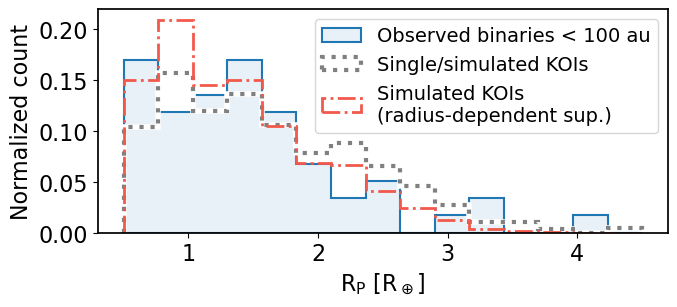

In [28]:
# Compare simulated planet radii to observed

for option in ['linear']:

    nbins=15

    if option=='linear':
        histrange=[0.5,4.5]
        bin_edges = np.linspace(histrange[0], histrange[1], nbins + 1)
    else:
        histrange=[np.log10(0.7),np.log10(6)]
        bin_edges = np.logspace(histrange[0], histrange[1], nbins + 1)
        
    bin_width = np.diff(bin_edges)
    bin_center = bin_edges[:-1]+bin_width/2.
        
    fig, axes = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)

    # Observed: binaries < 100 AU
    nplanets = len(binaries[binaries['SepAU']<100])
    ww = 1./np.full(nplanets, nplanets, dtype=float)
    y, _, _ = plt.hist(binaries[binaries['SepAU']<100]['prad_adopt'], 
                  bins=bin_edges, weights=ww,
             histtype='stepfilled', lw=1.5,
             edgecolor='#1f77b4', facecolor='#e8f1f7',
            label='Observed binaries < 100 au') 
    
    # Observed: presumed-single KOIs
    nplanets = len(singles)
    plt.hist(singles['koi_prad'], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=4, alpha=1, color='white')
    plt.hist(singles['koi_prad'], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',ls=':',
                 color='gray',  lw=3, 
            label='Single/simulated KOIs') 

    # Simulated: radius-dependent suppression
    nplanets = len(res_plradius.survived_planets)
    plt.hist(res_plradius.survived_planets['koi_prad'], 
                 bins=bin_edges,  weights = 1./np.full(nplanets, nplanets, dtype=float),
                 histtype='step',lw=2, linestyle='-.', color="#f2594b",
            label='Simulated KOIs \n(radius-dependent sup.)') 

    plt.ylabel('Normalized count')
    
    if option=='linear':
        plt.legend()
        plt.xlabel('$R_P$ [$R_\oplus$]')        
    else:
        plt.xlabel('$log_{10} R_P$ [$R_\oplus$]')  
        plt.xscale('log')
        
        custom_log_ticks = [1, 1.8, 3.5, 6]
        plt.gca().set_xticks(custom_log_ticks)
        plt.gca().set_xticklabels([str(t) for t in custom_log_ticks])
        
    plt.tight_layout()
    plt.savefig(f"plots/prad_{sup_method}_{tflag}.png")
    plt.xlim()
    
    
# Perform KS tests
print(f"\n=== {option} scale ===")
ks_stat, p_value =  stats.ks_2samp(binaries[binaries['SepAU']<100]['prad_adopt'], singles['koi_prad'])
print(f"KS statistic (binaries vs singles): {ks_stat}, p-value: {p_value}")

ks_stat, p_value = stats.ks_2samp(binaries[binaries['SepAU']<100]['prad_adopt'],res_systems.survived_planets['koi_prad'])
print(f"KS statistic (simulated systems vs singles): {ks_stat}, p-value: {p_value}")

ks_stat, p_value = stats.ks_2samp(binaries[binaries['SepAU']<100]['prad_adopt'], res_plradius.survived_planets['koi_prad'])
print(f"KS statistic (simulated radius-dependent vs singles): {ks_stat}, p-value: {p_value}")
    

## Semi-major axis plots


SEPARATION TEST:
a-values P-value (planets suppressed vs binaries)=35):
 KstestResult(statistic=0.13514533556536296, pvalue=0.5023450582285331, statistic_location=23.710137110257786, statistic_sign=-1)
a-values P-value (systems suppressed vs binaries)=35):
 KstestResult(statistic=0.09880431441993881, pvalue=0.8509794285690925, statistic_location=23.707439411078795, statistic_sign=-1)


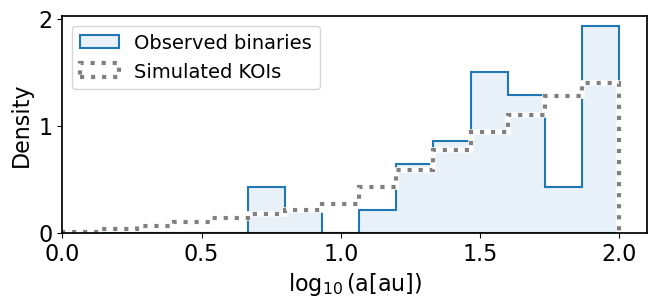

In [22]:
fig, ax = plt.subplots(1, 1, figsize=(7,3.3), sharex=True, sharey=True)
log_min, log_max = 0., np.log10(max_a_draw)              
n_bins = 15                             
bins   = np.linspace(log_min, log_max, n_bins + 1)   # bin edges

ax.set_xlabel(r'$\log_{10}(a [au])$')
ax.set_ylabel('Density')

sim = res_systems.survived_systems['a_values']
plt.hist(np.log10(sim), bins=bins,
         histtype='step', density=True, 
         color='white',  lw=4)
plt.hist(np.log10(sim), bins=bins,
         histtype='step', density=True, ls=':',
         color='gray',  lw=3, label='Simulated KOIs')


obs = binary_separations[binary_separations<max_a_draw]
obs2 = allbinaries_separations[allbinaries_separations<max_a_draw]
plt.hist(np.log10(obs), bins=bins, 
         density=True, histtype='stepfilled', ls='-',
         edgecolor='C0', facecolor='#e8f1f7', 
         alpha=1, lw=1.5, label='Observed binaries')


handles, labels = plt.gca().get_legend_handles_labels()
legend = plt.gca().legend(handles[::-1], labels[::-1], loc='upper left')
plt.xlim(log_min, log_max+0.1)
plt.tight_layout()

print("\nSEPARATION TEST:")

print("a-values P-value (planets suppressed vs binaries)=" + str(len(obs)) + "):\n", stats.ks_2samp(obs, res_planets.survived_systems['a_values']))
print("a-values P-value (systems suppressed vs binaries)=" + str(len(obs)) + "):\n", stats.ks_2samp(obs, res_systems.survived_systems['a_values']))



plt.savefig(f"plots/separation_{sup_method}_{tflag}.png")

## Multiplicity plots


RESULTS - MULTIPLICITY:
Close binary multiplicity: [0.62857143 0.2        0.08571429 0.02857143 0.05714286]
Wide binary multiplicity: [0.68055556 0.16666667 0.11111111 0.         0.04166667]
Singles multiplicity: [0.6875     0.20089286 0.07142857 0.02678571 0.01339286]
Planets suppressed simulated multiplicity: [0.82058743 0.13806118 0.03218993 0.00776138 0.00140009]
chi2 for multiplicity (systems suppressed): 0.5274431486765412
chi2 for multiplicity (planets suppressed): 0.0002175247313964599


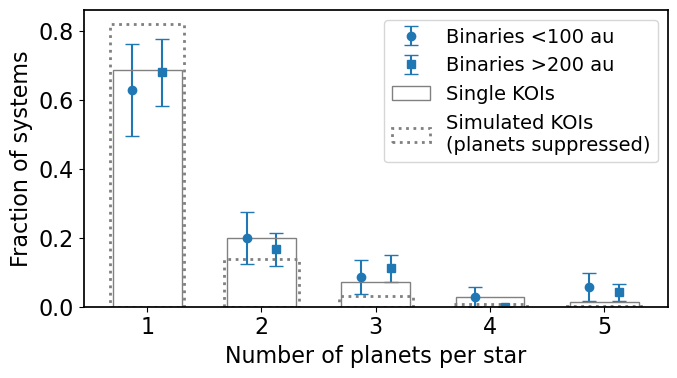

In [12]:

bin_label = 'Binaries <100 au'
bin_col = 'C0'
koi_label = 'Single KOIs'
close = binaries['SepAU']<100.
    
print("\nRESULTS - MULTIPLICITY:")

def plot_multiplicity_hist(planet_counts, norm_to=True, offset=0, plot_error=False, **kwargs):
    nstars = len(planet_counts)
    if norm_to:
        ww = norm_to/nstars
    else:
        ww = 1. / nstars

    y, _ = np.histogram(planet_counts['n_planets'], 
                        bins=[0.5,1.5,2.5,3.5,4.5,5.5])
    if plot_error == False:
        ax.bar(x + offset, y/nstars, **kwargs)

    if plot_error:
        ax.errorbar(x + offset, y/nstars, yerr=np.sqrt(y)/nstars, 
                    fmt=kwargs.get('fmt','o'), 
                    color=kwargs.get('edgecolor','C0'), 
                    capsize=5, elinewidth=1.5,
                    zorder=1, label=kwargs.get('label', None))
        
    return(y/nstars)



fig, ax = plt.subplots(1, 1, figsize=(7,4), sharex=True, sharey=True)
x = np.array([1,2,3,4,5])

## the binaries

bin_planet_counts = binaries[close].groupby('KOI').size().reset_index(name='n_planets')
y = plot_multiplicity_hist(bin_planet_counts, 
                        norm_to=False, plot_error=True, offset=-0.13,
                        edgecolor=bin_col, facecolor='#e8f1f7', alpha=1, 
                        width=0.9, linewidth=1.5,
                        label=bin_label, fmt='o')
print(f"Close binary multiplicity: {y}")

wide = binaries['SepAU']>200.
wide_planet_counts = binaries[wide].groupby('KOI').size().reset_index(name='n_planets')
y = plot_multiplicity_hist(wide_planet_counts, 
                        norm_to=False, plot_error=True, offset=0.13, #len(bin_planet_counts),
                        edgecolor=bin_col, facecolor='None', alpha=1, 
                        width=0.9, linewidth=1.5, ls='--', fmt='s',
                        label='Binaries >200 au')
print(f"Wide binary multiplicity: {y}")

singles_planet_counts = singles.groupby('KOI').size().reset_index(name='n_planets')
y = plot_multiplicity_hist(singles_planet_counts, 
                        norm_to=False, #len(bin_planet_counts),
                        #offset=-0.2,
                        ls='-', edgecolor='gray', facecolor='None',  
                        width=0.6, lw=1, label=koi_label)
print(f"Singles multiplicity: {y}")


y =plot_multiplicity_hist(res_planets.survived_systems, 
                        norm_to=False, #len(bin_planet_counts),
                        #offset=0.2,
                        ls=':', edgecolor='gray', facecolor='none',  
                        width=0.65, lw=2,
                        label='Simulated KOIs \n(planets suppressed)')
print(f"Planets suppressed simulated multiplicity: {y}")

plt.xlabel('Number of planets per star')
plt.ylabel('Fraction of systems')
plt.legend()
#plt.ylim(0,0.9)
plt.tight_layout()

plt.savefig(f'plots/multiplicity_{sup_method}_{tflag}.png')


p_chi2_systems = chisquare_multiplicity(bin_planet_counts, res_systems.survived_systems)
p_chi2_planets = chisquare_multiplicity(bin_planet_counts, res_planets.survived_systems)
print("chi2 for multiplicity (systems suppressed):", p_chi2_systems)
print("chi2 for multiplicity (planets suppressed):", p_chi2_planets)



## Complexity


RESULTS - COMPLEXITY:
Close binaries with >2 planets 6
Wide binaries with >2 planets 11
Complexity KS P-value (planets suppressed, N multis=2110): KstestResult(statistic=0.23285939968404423, pvalue=0.8363145834670591, statistic_location=0.0762941618097414, statistic_sign=1)
Complexity KS P-value (systems suppressed, N multis=15318): KstestResult(statistic=0.37256822039430737, pvalue=0.2969923664398817, statistic_location=0.07153942672762093, statistic_sign=1)


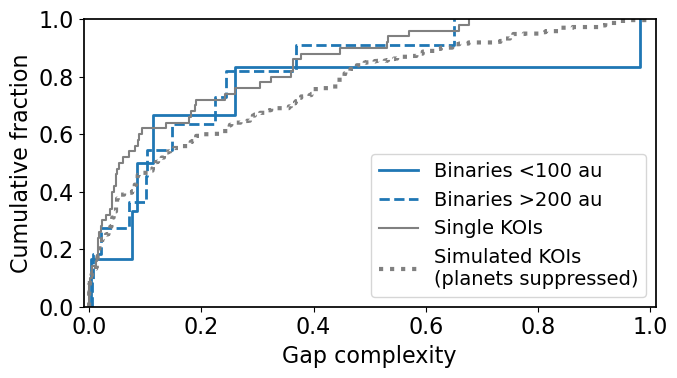

In [ ]:
koi_df = create_complexity_df(singles)
koi_complexity = koi_df[koi_df['n_planets']>2]['gap_complexity'].values

print("\nRESULTS - COMPLEXITY:")

def complexity_helper(sample, just_need_n=False, **kwargs):
    df = create_complexity_df(sample)
    complexity = df[np.isfinite(df['gap_complexity'])]['gap_complexity'].values
    if just_need_n:
        return len(complexity)
    
    sns.ecdfplot(complexity, **kwargs)

    return(complexity)

col = 'C0'
    
fig, ax = plt.subplots(figsize=(7, 4))

close_complexity = complexity_helper(binaries[binaries['SepAU']<100.], 
                  ax=ax, label='Binaries <100 au', linewidth=2, color=col)
print("Close binaries with >2 planets", len(close_complexity))  

wide_complexity = complexity_helper(binaries[binaries['SepAU']>=200.], 
                  ax=ax, label='Binaries >200 au', linewidth=2, ls='--',color=col)
print("Wide binaries with >2 planets", len(wide_complexity))  


sns.ecdfplot(koi_complexity, ax=ax,
             label='Single KOIs', color='gray')

plt.xlabel('Cumulative Fraction')
plt.ylabel('Complexity')

n_to_sample = complexity_helper(binaries[binaries['SepAU']<100.], just_need_n=True)

def complexity_sampler(res):

    samples = []
    for trial in res.survived_periods:
        df = create_complexity_df(trial)
        sample = df[np.isfinite(df['gap_complexity'])]['gap_complexity'].values

        samples =np.concatenate([samples, sample])

    return np.asarray(samples).flatten()

samples = complexity_sampler(res_planets)
print("Complexity KS P-value (planets suppressed, N multis=" + str(len(samples)) + "):", stats.ks_2samp(samples, close_complexity))
sns.ecdfplot(samples, ax=ax,
             label='Simulated KOIs \n(planets suppressed)', 
             color='gray', ls=':', lw=3)

samples = complexity_sampler(res_systems)
print("Complexity KS P-value (systems suppressed, N multis=" + str(len(samples)) + "):", stats.ks_2samp(samples, close_complexity))

plt.legend()
plt.xlim(-0.01,1.01)
plt.ylim(0,1)
plt.xlabel('Gap complexity')
plt.ylabel('Cumulative fraction')
                     
# and the appropriate stats

plt.tight_layout()
plt.savefig(f'plots/complexity_{sup_method}_{tflag}.png')

In [10]:
print("===========================================\n")
atexit.register(log_file.close)

<function TextIOWrapper.close()>